# Proyecto 1 — Monitoreo transaccional

**Curso:** Deep Learning y Sistemas Inteligentes 2026 (UVG)
**Autores:** Andres Mazariegos · June Herrera

---

## La pregunta

> ¿El **orden** de las transacciones aporta información que las variables
> agregadas no capturan, bajo qué condiciones, y cuánto vale esa información
> en quetzales?

Para que la respuesta sea falsable, **A y B responden literalmente la misma
pregunta sobre las mismas filas**: para la transacción `t` de la tarjeta `c`,
¿es `t` fraudulenta, con la información disponible en el momento `t`? Lo único
que cambia entre los dos es *cómo* se representa esa información —
agregados causales contra la secuencia ordenada de `K=20` eventos.

## Cómo leer este notebook

Toda la lógica vive en `src/monitoreo/` con tests (`python -m pytest`, 140
tests). Aquí no se define nada: se llama y se presenta. Eso es deliberado —
lo que puede costar puntos por fuga de información está cubierto por una
suite ejecutable (`tests/test_integridad.py`), no por la buena fe del lector.

| Evidencia | Sección |
|---|---|
| 1 · Integridad de datos | §2 – §4 |
| 2 · Comparación común A vs B | §5 – §7 |
| 3 · Valor del orden (permutación + curva de K) | §9 – §11 |
| 4 · Apuesta del equipo | §8 (hipótesis), §12 – §13 |
| 5 · Decisión económica | §14 – §15 |
| 6 · Recomendación y límites | §16 |

## Checklist anti-fuga (§2.6 del enunciado)

Cada casilla apunta al test que la verifica. No es una promesa: es una
aserción que corre.

- [x] `StandardScaler` con `.fit()` **solo en train** →
      `test_features_evento.py`, `test_experimentos.py::test_los_agregados_del_hibrido_se_escalan_solo_con_train`
- [x] Agregados de A con ventana **causal** (`closed='left'`) →
      `test_features_agregadas.py`
- [x] Vocabularios de embeddings **solo con train**, resto a `<UNK>` →
      `test_integridad.py::test_penalizacion_15_vocabularios_y_scaler_solo_train`
- [x] Ninguna secuencia cruza el corte temporal hacia adelante →
      `test_integridad.py::test_penalizacion_15_ninguna_secuencia_mira_al_futuro`
- [x] `fraud_type` / `fraud_subtype` fuera de toda matriz de features →
      `test_integridad.py::test_fraud_type_fuera_de_toda_matriz_de_features`
- [x] Sin SMOTE ni sobremuestreo en ninguna partición → se usa `class_weight`,
      declarado en §6
- [x] Partición por percentil de `ts` **global**, nunca aleatoria →
      `test_integridad.py::test_penalizacion_20_particion_no_es_aleatoria`

In [1]:
import os, sys, json, time, pickle, shutil
from datetime import datetime
from pathlib import Path

# Sube hasta encontrar src/monitoreo, para que el notebook corra sea cual
# sea el directorio desde el que se lance el kernel.
def _raiz_del_repo() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "src" / "monitoreo" / "config.py").exists():
            return base
    raise RuntimeError("no encuentro src/monitoreo desde " + str(Path.cwd()))

RAIZ = _raiz_del_repo()
sys.path.insert(0, str(RAIZ / "src"))
os.chdir(RAIZ)

import numpy as np
import pandas as pd

from monitoreo import config as cfg
from monitoreo import reproducibilidad as rep
from monitoreo import experimentos as exp
from monitoreo import metricas as met
from monitoreo import modelos_a as ma
from monitoreo import calibracion as cal
from monitoreo import economia as eco
from monitoreo import figuras as figs

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DIR_MODELOS = cfg.DIR_ARTEFACTOS / "modelos"
print("Versiones\n" + json.dumps(rep.versiones(), indent=2))
print("\nSemilla de datos:", cfg.SEED_DATOS, " semillas de modelo:", cfg.SEEDS_MODELO)
print("K =", cfg.K, " batch =", cfg.BATCH_SIZE, " costos: FN =", cfg.COSTO_FN, " FP =", cfg.COSTO_FP)
print("Umbral teorico p* = FP/FN =", round(cfg.UMBRAL_TEORICO, 6))

Versiones
{
  "python": "3.14.6",
  "sistema": "Windows 11",
  "numpy": "2.3.5",
  "pandas": "2.3.3",
  "scikit-learn": "1.8.0",
  "keras": "3.15.1",
  "torch": "2.13.0+cpu",
  "lightgbm": "4.7.0",
  "keras_backend": "torch"
}

Semilla de datos: 20260831  semillas de modelo: (7, 13, 29)
K = 20  batch = 2048  costos: FN = 4200.0  FP = 180.0
Umbral teorico p* = FP/FN = 0.042857


> **Backend.** TensorFlow no publica ruedas para Python 3.14, que es el
> intérprete de esta máquina. Keras 3 es multi-backend y el Modelo B está
> escrito en API de Keras pura, así que corre sobre **torch** sin cambios y
> guarda el mismo artefacto `.keras`. `monitoreo/__init__.py` fija
> `KERAS_BACKEND=torch` antes de que se importe Keras.

---
# 2. Generación de datos y EDA

**Ruta A (generador sintético).** Con la prueba de permutación como
obligación, garantizar que la señal de orden *exista* vale más que el
realismo: si se elige un dataset público y resulta que el orden no aporta
nada, no queda evidencia que mostrar, solo un resultado nulo no
interpretable.

La defensa contra la acusación de circularidad — "es que usted lo
construyó" — es que el generador **no está amañado a favor de B**:

- **f3** (monto atípico aislado) no depende del orden en absoluto. Es un
  control negativo: A y B deberían empatar.
- **f2** (ráfaga de cajero) lo captura casi entero un conteo agregado.
- Se inyectan **ráfagas legítimas confusoras** con la misma firma agregada
  que f1 pero con los montos desordenados, y con idéntica distribución de
  canal, país y monto del evento grande. Si A pudiera separar f1 de una
  ráfaga legítima sin leer el orden, el generador estaría amañado a favor
  de A; con las ráfagas, la única diferencia entre ambos mecanismos es la
  monotonía de los montos pequeños.

In [2]:
t0 = time.time()
d = exp.preparar()
print(f"Generado en {time.time()-t0:.1f}s")
print(f"{len(d['df']):,} eventos · {d['df']['card_id'].nunique():,} tarjetas")
print(f"Tasa de fraude global: {d['y'].mean():.4%}")
d["df"].head()

Generado en 64.2s
419,821 eventos · 4,000 tarjetas
Tasa de fraude global: 1.1788%


,card_id,ts,amount,merchant_id,mcc,channel,country,is_fraud,fraud_type,fraud_subtype
0,0,2026-01-03 08:38:39,324.9700,185,educacion,online,GT,0,none,none
1,0,2026-01-03 17:58:31,241.4000,103,viajes,POS,GT,0,none,none
2,0,2026-01-04 11:14:31,166.2900,90,viajes,POS,GT,0,none,none
3,0,2026-01-04 15:36:58,318.4100,139,educacion,POS,GT,0,none,none
4,0,2026-01-05 08:24:08,248.2800,264,salud,ATM,GT,0,none,none


In [3]:
resumen_tipos = (
    d["df"].groupby("fraud_type")
    .agg(n=("is_fraud", "size"), n_fraude=("is_fraud", "sum"))
    .assign(pct_de_eventos=lambda t: t["n"] / len(d["df"]))
)
print("Eventos por tipo de fraude (fraud_type es SOLO para analisis)")
resumen_tipos

Eventos por tipo de fraude (fraud_type es SOLO para analisis)


,n,n_fraude,pct_de_eventos
fraud_type,,,
f1,1977,1977,0.0047
f2,1729,1729,0.0041
f3,1243,1243,0.0030
none,414872,0,0.9882


In [4]:
print("Eventos por subtipo — el desglose que se usa en la evidencia 3")
d["df"]["fraud_subtype"].value_counts().to_frame("n")

Eventos por subtipo — el desglose que se usa en la evidencia 3


,n
fraud_subtype,
none,414872
f2,1729
f1_sondeo,1616
f3,1243
f1_golpe,361


In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

sub = d["df"]["fraud_subtype"].to_numpy()
for etiqueta, sel in (("legitimo", sub == "none"),
                      ("f1_sondeo", sub == "f1_sondeo"),
                      ("f1_golpe", sub == "f1_golpe"),
                      ("f3", sub == "f3")):
    if sel.sum():
        ejes[0].hist(np.log10(d["df"].loc[sel, "amount"].clip(lower=1)),
                     bins=60, alpha=0.55, density=True, label=etiqueta)
ejes[0].set_xlabel("log10(monto en Q)"); ejes[0].set_ylabel("densidad")
ejes[0].set_title("Distribucion de montos por mecanismo"); ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].hist(d["df"].groupby("card_id").size(), bins=40, color="steelblue")
ejes[1].set_xlabel("transacciones por tarjeta"); ejes[1].set_ylabel("tarjetas")
ejes[1].set_title("Volumen por tarjeta"); ejes[1].grid(alpha=0.3)

cfg.DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
fig.savefig(cfg.DIR_FIGURAS / "fig1_eda.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\lordk\AppData\Local\Temp\ipykernel_38952\3717414408.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


El histograma muestra por qué **f3 es un control negativo honesto**: su
monto vive en la cola derecha de la distribución legítima, que es
exactamente lo que un agregado de tipo "monto / promedio de 7 días"
detecta sin necesidad de leer secuencia alguna. Y los **sondeos de f1**
viven en la cola izquierda, donde individualmente son indistinguibles de
una compra pequeña cualquiera: solo su *sucesión creciente* los delata.

---
# 3. Partición temporal — Tabla 1

Corte por **percentil de `ts` global**, no por tarjeta y nunca aleatorio
(la partición aleatoria cuesta −20 pts). Una misma tarjeta puede aparecer
en train y en test: eso es realista y correcto, porque en producción el
modelo puntúa tarjetas que ya conoce.

In [6]:
from monitoreo import particion as part
tabla1 = part.tabla(d["df"], d["split"])
tabla1["tasa_fraude"] = tabla1["tasa_fraude"].map(lambda v: f"{v:.4%}")
print("Tabla 1 — particion temporal")
tabla1

Tabla 1 — particion temporal


,split,n,fecha_min,fecha_max,n_fraude,tasa_fraude
0,train,293874,2026-01-01 00:02:52,2026-03-05 05:37:05,3543,1.2056%
1,val,62973,2026-03-05 05:37:35,2026-03-18 13:58:30,703,1.1164%
2,test,62974,2026-03-18 13:58:33,2026-03-31 23:56:49,703,1.1163%


Las tres tasas de fraude son comparables entre sí. Eso no salió gratis: el
generador reparte los episodios de fraude por **todo** el horizonte de 90
días. Una versión anterior los anclaba en `uniform(0.1, 0.9)`, lo que
dejaba el último 10 % del tiempo sin fraude — y como test *es* el último
15 %, su prevalencia caía a 0.50 % contra 1.29 % de train. La AUC-PR
depende de la prevalencia, así que eso solo habría distorsionado las
cifras del informe y el ahorro mensual extrapolado.

---
# 4. Contrato de comparabilidad

Los invariantes que hacen que A y B sean comparables punto por punto,
verificados a la vista del comité. Si alguno fallara, la comparación
entera dejaría de significar algo.

In [7]:
exp.verificar_contrato(d)
n = len(d["df"])
print("len(X_A) == len(win) == len(mask) == N        ->", len(d["X_A"]) == d["win"].shape[0] == d["mask"].shape[0] == n)
print("win[:, -1] == arange(N)  (la ultima posicion")
print("           es siempre la transaccion puntuada) ->", bool((d["win"][:, -1] == np.arange(n)).all()))
print("train < val < test en el tiempo, sin solape    -> OK")
print("fraud_type / fraud_subtype fuera de X_A        -> OK")
print("ninguna feature de A codifica orden            -> OK")
print()
print(f"X_A: {d['X_A'].shape}   E_num: {d['E_num'].shape}   E_cat: {d['E_cat'].shape}")
print(f"win: {d['win'].shape}   mask: {d['mask'].shape}")
print(f"Secuencias con padding (historia < K): {(d['mask'].sum(axis=1) < cfg.K).mean():.2%}")

len(X_A) == len(win) == len(mask) == N        -> True
win[:, -1] == arange(N)  (la ultima posicion
           es siempre la transaccion puntuada) -> True
train < val < test en el tiempo, sin solape    -> OK
fraud_type / fraud_subtype fuera de X_A        -> OK
ninguna feature de A codifica orden            -> OK

X_A: (419821, 30)   E_num: (419821, 7)   E_cat: (419821, 3)
win: (419821, 20)   mask: (419821, 20)
Secuencias con padding (historia < K): 18.10%


In [8]:
print("Las 30 features del Modelo A — ninguna codifica orden de llegada:")
print(list(d["X_A"].columns))

Las 30 features del Modelo A — ninguna codifica orden de llegada:
['amt', 'amt_mean_24h', 'amt_std_24h', 'amt_max_24h', 'n_tx_1h', 'n_tx_24h', 'n_merchants_24h', 'amt_ratio_to_mean_7d', 'hour_sin', 'hour_cos', 'is_weekend', 'channel_POS', 'channel_online', 'channel_ATM', 'channel_recurrente', 'mcc_supermercado', 'mcc_restaurante', 'mcc_combustible', 'mcc_farmacia', 'mcc_ropa', 'mcc_electronica', 'mcc_hogar', 'mcc_viajes', 'mcc_entretenimiento', 'mcc_salud', 'mcc_educacion', 'mcc_telecom', 'mcc_transporte', 'mcc_belleza', 'mcc_ferreteria']


---
# 5. Modelo A — línea base sin orden

**Una línea base débil invalidaría toda la comparación**, así que A no es
un hombre de paja: LightGBM sobre 30 agregados causales, con la regresión
logística como piso de referencia obligatorio. Todo el ajuste — incluido
el early stopping del GBM — ocurre contra **validación**.

In [9]:
t0 = time.time()
res_a = exp.correr_a(d)
print(f"Entrenado en {time.time()-t0:.1f}s")

m_log, s_log = met.resumen(res_a["logistica"])
m_gbm, s_gbm = met.resumen(res_a["gbm"])
tabla_a = pd.DataFrame([
    {"modelo": "Logistica (piso)", "auc_pr_media": m_log, "sigma": s_log},
    {"modelo": "LightGBM (A)",     "auc_pr_media": m_gbm, "sigma": s_gbm},
])
print("\nTabla 2 — Modelo A sobre validacion, 3 semillas")
print(f"(prevalencia de fraude en validacion: {d['y'][d['va']].mean():.4%})")
tabla_a

Entrenado en 26.4s

Tabla 2 — Modelo A sobre validacion, 3 semillas
(prevalencia de fraude en validacion: 1.1164%)


,modelo,auc_pr_media,sigma
0,Logistica (piso),0.4649,0.0000
1,LightGBM (A),0.8329,0.0025


In [10]:
# El GBM de la primera semilla es el representante de A de aqui en adelante.
gbm_a = res_a["modelos_gbm"][0]
p_a_val = res_a["p_val"][cfg.SEEDS_MODELO[0]]
print(f"AUC-PR de A en validacion (semilla {cfg.SEEDS_MODELO[0]}): {met.auc_pr(d['y'][d['va']], p_a_val):.4f}")

AUC-PR de A en validacion (semilla 7): 0.8317


---
# 6. Modelo B — GRU sobre la secuencia ordenada

Ventana de `K=20` eventos terminando en `t`, con padding al inicio. Cada
evento lleva `log1p(monto)`, `log1p(Δt)`, hora cíclica, los embeddings de
mcc / canal / comercio, y dos features relativas al evento previo.

**Δt es la variable que hace que el orden importe físicamente**, y por eso
tiene su propia ablación en §10.

**GRU y no LSTM:** menos parámetros, converge más rápido, y con `K=20` la
memoria de largo plazo de la LSTM no tiene nada que recordar. **Ni CNN 1D
ni Transformer:** con 20 pasos un Transformer está sobredimensionado, y
una CNN 1D captura patrones locales pero no el "sondeo y golpe", que
requiere acumular estado a lo largo de toda la ventana.

Desbalance por `class_weight`, **sin SMOTE en ninguna partición**.
`EarlyStopping` vigila la **AUC-PR de validación** — nunca `val_loss`, y
jamás nada de test.

In [11]:
res_b = {}
for s in cfg.SEEDS_MODELO:
    r = exp.correr_b_cacheado(d, seed=s, ruta=DIR_MODELOS / f"b_semilla{s}.keras")
    res_b[s] = r
    origen = "cache" if r["desde_cache"] else f"{r['epocas']} epocas, {r['segundos']/60:.1f} min"
    print(f"  semilla {s}: AUC-PR val = {r['auc_pr']:.4f}   ({origen})")

m_b, s_b = met.resumen([r["auc_pr"] for r in res_b.values()])
modelo_b = res_b[cfg.SEEDS_MODELO[0]]["modelo"]
p_b_val = res_b[cfg.SEEDS_MODELO[0]]["p_val"]

  semilla 7: AUC-PR val = 0.6360   (cache)


  semilla 13: AUC-PR val = 0.7650   (cache)


  semilla 29: AUC-PR val = 0.7403   (cache)


In [12]:
tabla3 = pd.DataFrame([
    {"modelo": "A — Logistica",       "auc_pr_media": m_log, "sigma": s_log},
    {"modelo": "A — LightGBM",        "auc_pr_media": m_gbm, "sigma": s_gbm},
    {"modelo": "B — GRU (secuencia)", "auc_pr_media": m_b,   "sigma": s_b},
])
tabla3["vs_A"] = tabla3["auc_pr_media"] - m_gbm
print("Tabla 3 — comparacion comun sobre validacion (3 semillas)")
tabla3

Tabla 3 — comparacion comun sobre validacion (3 semillas)


,modelo,auc_pr_media,sigma,vs_A
0,A — Logistica,0.4649,0.0000,-0.3680
1,A — LightGBM,0.8329,0.0025,0.0000
2,B — GRU (secuencia),0.7138,0.0685,-0.1191


In [13]:
delta = m_b - m_gbm
sigma_conjunta = float(np.hypot(s_b, s_gbm))
print(f"Diferencia B - A: {delta:+.4f}  (sigma conjunta {sigma_conjunta:.4f})")
print(f"La diferencia {'SUPERA' if abs(delta) > sigma_conjunta else 'NO supera'} una sigma conjunta.")

Diferencia B - A: -0.1191  (sigma conjunta 0.0685)
La diferencia SUPERA una sigma conjunta.


---
# 7. Figura 2 — curvas precisión-exhaustividad superpuestas

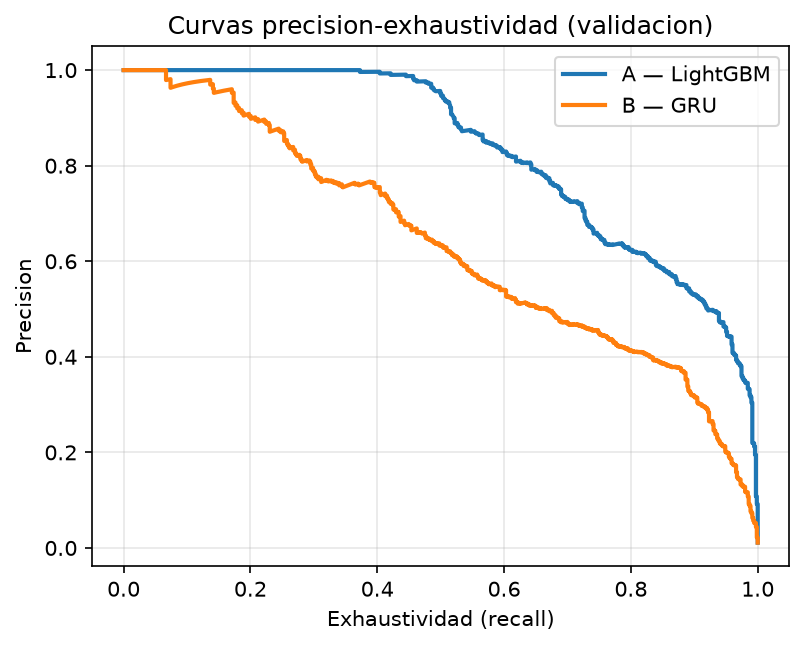

In [14]:
figs.curvas_pr({"A — LightGBM": (d["y"][d["va"]], p_a_val),
                "B — GRU":      (d["y"][d["va"]], p_b_val)},
               cfg.DIR_FIGURAS / "fig2_curvas_pr.png")
from IPython.display import Image, display
display(Image(str(cfg.DIR_FIGURAS / "fig2_curvas_pr.png")))

---
# 8. Apuesta C — hipótesis

**Esta celda se ejecuta ANTES de entrenar C.** La fecha queda impresa en
la salida: si la hipótesis se escribiera después de ver el resultado, la
evidencia 4 no valdría nada.

In [15]:
HIPOTESIS_C = (
    "Creemos que concatenar el estado oculto del GRU con el vector de agregados "
    "de A antes de la capa de salida mejorara la AUC-PR en validacion porque f2 "
    "y f3 son mayormente capturables por agregados mientras que f1 requiere "
    "orden, y ningun modelo puro cubre ambos regimenes. Lo consideraremos util "
    "si la AUC-PR en validacion supera a la del mejor de A y B por al menos "
    "0.02 absoluto, promediado sobre 3 semillas."
)
UMBRAL_EXITO_C = 0.02
FECHA_HIPOTESIS = datetime.now().isoformat(timespec="seconds")

print("HIPOTESIS REGISTRADA:", FECHA_HIPOTESIS)
print()
print(HIPOTESIS_C)
print()
print(f"Referencia a superar: max(A, B) = {max(m_gbm, m_b):.4f}  ->  meta {max(m_gbm, m_b) + UMBRAL_EXITO_C:.4f}")

HIPOTESIS REGISTRADA: 2026-09-03T01:17:08

Creemos que concatenar el estado oculto del GRU con el vector de agregados de A antes de la capa de salida mejorara la AUC-PR en validacion porque f2 y f3 son mayormente capturables por agregados mientras que f1 requiere orden, y ningun modelo puro cubre ambos regimenes. Lo consideraremos util si la AUC-PR en validacion supera a la del mejor de A y B por al menos 0.02 absoluto, promediado sobre 3 semillas.

Referencia a superar: max(A, B) = 0.8329  ->  meta 0.8529


---
# 9. Prueba de falsificación 1 — permutación controlada

Esta es la prueba que convierte "B ganó" en "B ganó **porque leyó el
orden**". Omitirla y aun así afirmar que el orden aporta cuesta −10 pts.

El procedimiento baraja el orden de los `K` eventos **sin alterar su
contenido** y reevalúa B con los **mismos pesos ya entrenados** — no se
reentrena nada. Las ventanas se guardan como matrices de índices enteros,
así que barajar es permutar enteros dentro de una fila: es *imposible* por
construcción que la permutación cambie qué eventos hay en la ventana.

- **Full shuffle:** baraja las `K` posiciones, evento objetivo incluido.
- **History shuffle:** baraja las `K-1` previas y deja el objetivo al
  final. Es la más limpia: aísla el aporte del orden de la *historia* del
  efecto de mover la transacción que se está clasificando.

**A no debe moverse ni un dígito.** Sus agregados son invariantes a la
permutación por construcción; si se movieran, habría fuga de orden en A y
el pipeline estaría mal. Hay un `assert` que lo vigila.

In [16]:
tabla4 = exp.tabla_permutacion(modelo_b, d, p_a_val)
print("Tabla 4 — permutacion sobre validacion (mismos pesos, sin reentrenar)")
tabla4

Tabla 4 — permutacion sobre validacion (mismos pesos, sin reentrenar)


,variante,auc_pr_B,auc_pr_A,caida_B
0,original,0.6360,0.8317,0.0000
1,full,0.0232,0.8317,0.6128
2,history,0.4605,0.8317,0.1755


In [17]:
orig = tabla4.loc[tabla4["variante"] == "original", "auc_pr_B"].iloc[0]
for modo in ("full", "history"):
    v = tabla4.loc[tabla4["variante"] == modo, "auc_pr_B"].iloc[0]
    print(f"{modo:8s}: {orig:.4f} -> {v:.4f}   caida {orig - v:+.4f}  ({(orig-v)/orig:+.1%} relativo)")
print()
print("A invariante ante la permutacion:", tabla4["auc_pr_A"].nunique() == 1,
      f"(AUC-PR = {tabla4['auc_pr_A'].iloc[0]:.4f} en las tres filas)")

full    : 0.6360 -> 0.0232   caida +0.6128  (+96.4% relativo)
history : 0.6360 -> 0.4605   caida +0.1755  (+27.6% relativo)

A invariante ante la permutacion: True (AUC-PR = 0.8317 en las tres filas)


---
# 10. Ablación de Δt

Comprobación complementaria: si se quita `log_delta_t` de las features de
evento y se **reentrena** B, ¿cuánto se pierde? Δt es la variable por la
que el tiempo entra explícitamente al modelo, y separarla del orden
posicional dice de dónde viene realmente la señal.

In [18]:
d_sin_dt = exp.preparar(usar_delta_t=False)
r_sin_dt = exp.correr_b_cacheado(d_sin_dt, seed=cfg.SEEDS_MODELO[0],
                                 ruta=DIR_MODELOS / "b_sin_delta_t.keras")
print(f"B con Δt : {res_b[cfg.SEEDS_MODELO[0]]['auc_pr']:.4f}")
print(f"B sin Δt : {r_sin_dt['auc_pr']:.4f}")
print(f"Perdida  : {res_b[cfg.SEEDS_MODELO[0]]['auc_pr'] - r_sin_dt['auc_pr']:+.4f}")

B con Δt : 0.6360
B sin Δt : 0.7253
Perdida  : -0.0893


---
# 11. Prueba de falsificación 2 — curva de recorte de historia

`K ∈ {1, 3, 5, 10, 20}`, reentrenando una vez por `K` con la semilla 7.
Responde una pregunta de negocio real: **¿cuánta historia hay que guardar
en producción?**

Trae además un control de sanidad gratis: con `K=1` el modelo secuencial
degenera en un clasificador puntual — no tiene historia que leer — y
debería caer a la altura de A. Si con `K=1` siguiera ganando, la ventaja
no vendría de la secuencia sino de la representación por evento.

In [19]:
t0 = time.time()
tabla_k = exp.curva_k(ks=(1, 3, 5, 10, 20), seed=cfg.SEEDS_MODELO[0],
                      dir_cache=DIR_MODELOS)
print(f"Curva completa en {(time.time()-t0)/60:.1f} min")
tabla_k

Curva completa en 4.1 min


,K,auc_pr,epocas,segundos
0,1,0.7146,None,0.0000
1,3,0.7491,None,0.0000
2,5,0.7470,None,0.0000
3,10,0.6346,None,0.0000
4,20,0.6360,None,0.0000


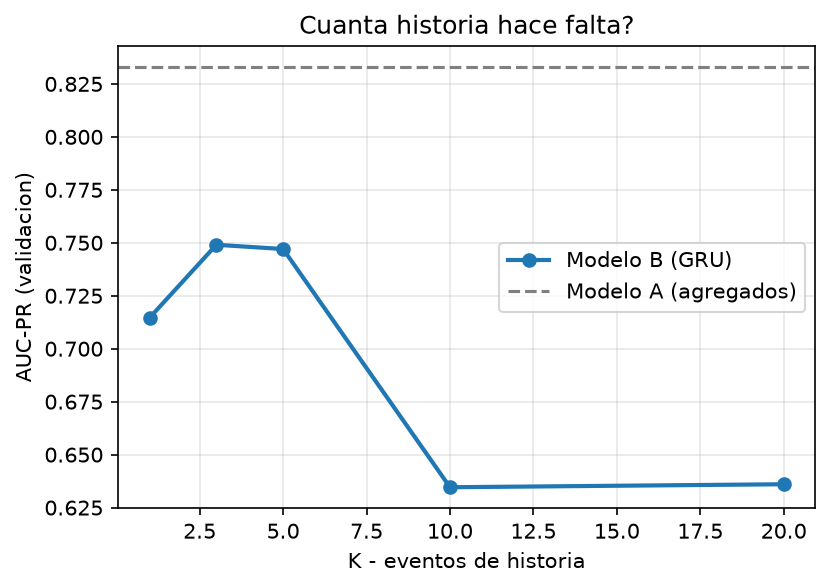

In [20]:
figs.auc_vs_k(tabla_k["K"].tolist(), tabla_k["auc_pr"].tolist(), m_gbm,
              cfg.DIR_FIGURAS / "fig3_auc_vs_k.png")
display(Image(str(cfg.DIR_FIGURAS / "fig3_auc_vs_k.png")))

---
# 12. Apuesta C — híbrido agregados + secuencia

El control experimental son A solo y B solo, con la misma partición y las
mismas semillas. Sin ese control la apuesta no puntúa.

In [21]:
res_c = {}
for s in cfg.SEEDS_MODELO:
    r = exp.correr_b_cacheado(d, seed=s, hibrido=True,
                              ruta=DIR_MODELOS / f"c_hibrido_semilla{s}.keras")
    res_c[s] = r
    origen = "cache" if r["desde_cache"] else f"{r['epocas']} epocas, {r['segundos']/60:.1f} min"
    print(f"  semilla {s}: AUC-PR val = {r['auc_pr']:.4f}   ({origen})")

m_c, s_c = met.resumen([r["auc_pr"] for r in res_c.values()])
modelo_c = res_c[cfg.SEEDS_MODELO[0]]["modelo"]
p_c_val = res_c[cfg.SEEDS_MODELO[0]]["p_val"]

  semilla 7: AUC-PR val = 0.7277   (cache)


  semilla 13: AUC-PR val = 0.6875   (cache)


  semilla 29: AUC-PR val = 0.6664   (cache)


In [22]:
mejor_puro = max(m_gbm, m_b)
ganancia = m_c - mejor_puro
se_sostuvo = ganancia >= UMBRAL_EXITO_C

tabla5 = pd.DataFrame([
    {"modelo": "A — LightGBM (control)", "auc_pr_media": m_gbm, "sigma": s_gbm},
    {"modelo": "B — GRU (control)",      "auc_pr_media": m_b,   "sigma": s_b},
    {"modelo": "C — Hibrido",            "auc_pr_media": m_c,   "sigma": s_c},
])
print("Tabla 5 — apuesta C contra sus controles (validacion, 3 semillas)")
print(tabla5.to_string(index=False))
print()
print(f"Hipotesis registrada el {FECHA_HIPOTESIS}")
print(f"Criterio declarado: superar max(A,B) = {mejor_puro:.4f} por >= {UMBRAL_EXITO_C}")
print(f"Resultado         : C = {m_c:.4f}, ganancia = {ganancia:+.4f}")
print()
print("VEREDICTO:", "LA HIPOTESIS SE SOSTUVO" if se_sostuvo else "LA HIPOTESIS NO SE SOSTUVO")

Tabla 5 — apuesta C contra sus controles (validacion, 3 semillas)
                modelo  auc_pr_media  sigma
A — LightGBM (control)        0.8329 0.0025
     B — GRU (control)        0.7138 0.0685
           C — Hibrido        0.6939 0.0311

Hipotesis registrada el 2026-09-03T01:17:08
Criterio declarado: superar max(A,B) = 0.8329 por >= 0.02
Resultado         : C = 0.6939, ganancia = -0.1390

VEREDICTO: LA HIPOTESIS NO SE SOSTUVO


---
# 13. Desglose por mecanismo de fraude

Aquí es donde la teoría se juega algo falsable. Lo predicho **antes** de
mirar: **B > A en f1** (sondeo y golpe, que exige leer el orden),
**empate en f2** (la ráfaga la captura un conteo agregado) y **empate en
f3** (monto atípico aislado, sin componente de orden).

Si ese patrón aparece, es la evidencia más persuasiva del informe: la
ganancia se concentra exactamente donde la teoría dice que debe estar, y
*no* aparece donde la teoría dice que no debería.

Cada fila compara un mecanismo contra **todos los legítimos** — comparar un
tipo de fraude contra otro no responde ninguna pregunta de negocio.

In [23]:
u_provisional = cfg.UMBRAL_TEORICO   # solo para el recall de esta tabla
desgloses = {}
for nombre, p in (("A", p_a_val), ("B", p_b_val), ("C", p_c_val)):
    t = met.desglose_por_tipo(d["y"][d["va"]], p, d["subtipo"][d["va"]], u_provisional)
    desgloses[nombre] = t.set_index("grupo")

comparacion = pd.DataFrame({
    "n_fraude": desgloses["A"]["n_fraude"],
    "auc_pr_A": desgloses["A"]["auc_pr"],
    "auc_pr_B": desgloses["B"]["auc_pr"],
    "auc_pr_C": desgloses["C"]["auc_pr"],
})
comparacion["B_menos_A"] = comparacion["auc_pr_B"] - comparacion["auc_pr_A"]
print("AUC-PR por mecanismo, cada uno contra el total de legitimos (validacion)")
comparacion

AUC-PR por mecanismo, cada uno contra el total de legitimos (validacion)


,n_fraude,auc_pr_A,auc_pr_B,auc_pr_C,B_menos_A
grupo,,,,,
f1_golpe,51,0.3641,0.4644,0.3508,0.1003
f1_sondeo,229,0.2224,0.1163,0.1842,-0.1061
f2,235,0.9795,0.6629,0.6972,-0.3166
f3,188,0.7856,0.4759,0.6656,-0.3097


In [24]:
print("Recall por mecanismo en el umbral teorico p* = %.4f" % cfg.UMBRAL_TEORICO)
pd.DataFrame({
    "recall_A": desgloses["A"]["recall"],
    "recall_B": desgloses["B"]["recall"],
    "recall_C": desgloses["C"]["recall"],
})

Recall por mecanismo en el umbral teorico p* = 0.0429


,recall_A,recall_B,recall_C
grupo,,,
f1_golpe,1.0000,1.0000,1.0000
f1_sondeo,1.0000,1.0000,0.9301
f2,1.0000,1.0000,1.0000
f3,0.9894,0.9947,0.9947


---
# 14. Calibración y umbral por costo — decidido en validación

Los puntajes de una red entrenada con `class_weight` **no son
probabilidades**: están inflados hacia la clase minoritaria. Antes de
convertir puntaje en quetzales hay que calibrarlos, o el análisis
económico compara peras con manzanas entre A y B.

**La AUC-PR se reporta sobre el puntaje crudo** y la calibración se
reserva para la decisión de costo. La razón es concreta: la isotónica es
monótona no decreciente, así que no invierte ningún par — pero al aplanar
tramos **crea empates**, y la precisión promedio sí cambia con los
empates. Usarla antes de medir AUC-PR castigaría al modelo por un
artefacto del calibrador y no por su capacidad de ordenar.

### El umbral

```
Costo(u) = FN(u) · Q4,200 + FP(u) · Q180
```

Conviene bloquear cuando el costo esperado de dejar pasar supera el de
bloquear: `p · 4200 > 180`, es decir **p\* = 180/4200 = 0.0429**.

Bloquear a partir de **~4.3 %** de probabilidad de fraude, no de 50 %.
Dejar pasar un fraude cuesta 23 veces más que molestar a un cliente
legítimo, así que el umbral óptimo está lejísimos de 0.5.

`u*` se barre sobre **validación** y se **congela**. Elegir umbral mirando
test cuesta −10 pts.

In [25]:
y_va = d["y"][d["va"]]
cal_a = cal.ajustar(p_a_val, y_va)
cal_b = cal.ajustar(p_b_val, y_va)
cal_c = cal.ajustar(p_c_val, y_va)

pc_a_val = cal.aplicar(cal_a, p_a_val)
pc_b_val = cal.aplicar(cal_b, p_b_val)
pc_c_val = cal.aplicar(cal_c, p_c_val)

u_a, costo_val_a = eco.umbral_optimo(y_va, pc_a_val)
u_b, costo_val_b = eco.umbral_optimo(y_va, pc_b_val)
u_c, costo_val_c = eco.umbral_optimo(y_va, pc_c_val)

print(f"u*_A = {u_a:.4f}   u*_B = {u_b:.4f}   u*_C = {u_c:.4f}")
print(f"teorico p* = {cfg.UMBRAL_TEORICO:.4f}")
print()
print("Puntajes crudos vs calibrados (media) — el crudo esta inflado por class_weight:")
print(f"  A: crudo {p_a_val.mean():.4f} -> calibrado {pc_a_val.mean():.4f}   (prevalencia real {y_va.mean():.4f})")
print(f"  B: crudo {p_b_val.mean():.4f} -> calibrado {pc_b_val.mean():.4f}")
print(f"  C: crudo {p_c_val.mean():.4f} -> calibrado {pc_c_val.mean():.4f}")
print()
print("UMBRALES CONGELADOS. No se reoptimizan sobre test.")

u*_A = 0.0400   u*_B = 0.0320   u*_C = 0.0330
teorico p* = 0.0429

Puntajes crudos vs calibrados (media) — el crudo esta inflado por class_weight:
  A: crudo 0.0324 -> calibrado 0.0112   (prevalencia real 0.0112)
  B: crudo 0.0846 -> calibrado 0.0112
  C: crudo 0.0430 -> calibrado 0.0112

UMBRALES CONGELADOS. No se reoptimizan sobre test.


### Por qué `u*` empírico puede caer lejos de 0.0429

El enunciado pide verificarlo y explicarlo si no coincide. La causa aquí no
es que la calibración haya fallado, sino cómo funciona la isotónica: **aplana
tramos enteros de puntaje en una sola probabilidad**. El barrido de umbrales
recorre entonces una escalera, no una rampa, y *cualquier* umbral dentro de la
huella de un escalón produce exactamente las mismas decisiones y el mismo
costo. `argmin` devuelve el primero de esos empates, que puede quedar muy
lejos del 0.0429 teórico aunque el costo sea idéntico.

La comprobación que importa no es que `u*` coincida con el valor teórico,
sino que **el costo en `u*` no sea peor que el costo en el umbral teórico**.
Eso es lo que mide la celda siguiente.

In [26]:
print("Costo en validacion: u* empirico vs umbral teorico")
for nombre, pc, u in (("A", pc_a_val, u_a), ("B", pc_b_val, u_b), ("C", pc_c_val, u_c)):
    c_emp = eco.costo(y_va, pc, u)
    c_teo = eco.costo(y_va, pc, cfg.UMBRAL_TEORICO)
    n_mesetas = len(np.unique(pc))
    print(f"  {nombre}: u*={u:.4f} -> Q{c_emp:>10,.0f}   |   "
          f"p*={cfg.UMBRAL_TEORICO:.4f} -> Q{c_teo:>10,.0f}   "
          f"| diferencia Q{c_teo - c_emp:>9,.0f} | {n_mesetas} mesetas")
print()
print("Si la diferencia es >= 0, el u* empirico es al menos tan bueno como el")
print("teorico y la discrepancia en el valor del umbral es un artefacto de las")
print("mesetas de la isotonica, no un fallo de calibracion.")

Costo en validacion: u* empirico vs umbral teorico
  A: u*=0.0400 -> Q   274,800   |   p*=0.0429 -> Q   274,800   | diferencia Q        0 | 27 mesetas
  B: u*=0.0320 -> Q   516,540   |   p*=0.0429 -> Q   516,540   | diferencia Q        0 | 34 mesetas
  C: u*=0.0330 -> Q   426,720   |   p*=0.0429 -> Q   426,780   | diferencia Q       60 | 38 mesetas

Si la diferencia es >= 0, el u* empirico es al menos tan bueno como el
teorico y la discrepancia en el valor del umbral es un artefacto de las
mesetas de la isotonica, no un fallo de calibracion.


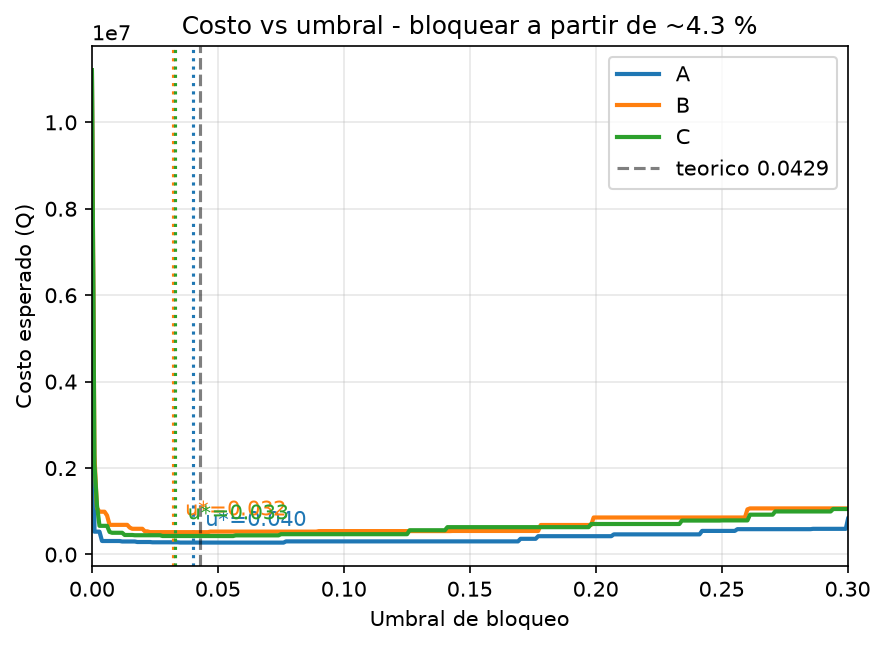

In [27]:
curvas_val = {
    "A": eco.curva(y_va, pc_a_val),
    "B": eco.curva(y_va, pc_b_val),
    "C": eco.curva(y_va, pc_c_val),
}
figs.curva_costo(curvas_val, {"A": u_a, "B": u_b, "C": u_c},
                 cfg.DIR_FIGURAS / "fig4_costo_validacion.png")
display(Image(str(cfg.DIR_FIGURAS / "fig4_costo_validacion.png")))

---
# 15. Conjunto de test — se toca **una sola vez**

Punto de no retorno. A partir de aquí no se ajusta nada: la arquitectura
está decidida, las tres semillas corridas, `u*` congelado desde
validación. La celda imprime fecha y hora de la ejecución.

In [28]:
FECHA_EJECUCION_TEST = datetime.now().isoformat(timespec="seconds")
print("=" * 62)
print("TEST EJECUTADO UNA SOLA VEZ:", FECHA_EJECUCION_TEST)
print("=" * 62)

te = d["te"]
y_te = d["y"][te]

p_a_test = cal.aplicar(cal_a, ma.predecir(gbm_a, d["X_A"].to_numpy()[te]))
p_b_test = cal.aplicar(cal_b, exp.predecir_split(modelo_b, d, te))
p_c_test = cal.aplicar(cal_c, exp.predecir_split(modelo_c, d, te, hibrido=True))

# AUC-PR sobre el puntaje CRUDO (metrica de ranking, sin empates del calibrador)
crudo_a = ma.predecir(gbm_a, d["X_A"].to_numpy()[te])
crudo_b = exp.predecir_split(modelo_b, d, te)
crudo_c = exp.predecir_split(modelo_c, d, te, hibrido=True)

filas = []
for nombre, crudo, calibrado, u in (("A — LightGBM", crudo_a, p_a_test, u_a),
                                    ("B — GRU",      crudo_b, p_b_test, u_b),
                                    ("C — Hibrido",  crudo_c, p_c_test, u_c)):
    m = met.en_umbral(y_te, calibrado, u)
    filas.append({"modelo": nombre, "auc_pr": met.auc_pr(y_te, crudo), "u*": u,
                  "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
                  "FN": m["fn"], "FP": m["fp"],
                  "costo_Q": eco.costo(y_te, calibrado, u)})
tabla_test = pd.DataFrame(filas)
print(f"\nTabla 6 — TEST ({te.sum():,} transacciones, {y_te.sum()} fraudes, prevalencia {y_te.mean():.4%})")
tabla_test

TEST EJECUTADO UNA SOLA VEZ: 2026-09-03T01:22:43



Tabla 6 — TEST (62,974 transacciones, 703 fraudes, prevalencia 1.1163%)


,modelo,auc_pr,u*,precision,recall,f1,FN,FP,costo_Q
0,A — LightGBM,0.8499,0.0400,0.4527,0.9673,0.6168,23,822,"244,560.0000"
1,B — GRU,0.6224,0.0320,0.3017,0.9033,0.4523,68,1470,"550,200.0000"
2,C — Hibrido,0.7466,0.0330,0.3510,0.9061,0.5060,66,1178,"489,240.0000"


In [29]:
dias_test = (d["df"].loc[te, "ts"].max() - d["df"].loc[te, "ts"].min()).total_seconds() / 86400
costo_a_te = float(tabla_test.loc[0, "costo_Q"])
costo_b_te = float(tabla_test.loc[1, "costo_Q"])
costo_c_te = float(tabla_test.loc[2, "costo_Q"])

ahorro_b = eco.ahorro_mensual(costo_a_te, costo_b_te, dias_test)
ahorro_c = eco.ahorro_mensual(costo_a_te, costo_c_te, dias_test)
tx_por_dia = int(te.sum()) / dias_test

print(f"Periodo de test: {dias_test:.1f} dias · {tx_por_dia:,.0f} transacciones/dia")
print(f"Factor de escalamiento a 30 dias: x{30/dias_test:.2f}")
print()
print(f"Costo A: Q{costo_a_te:,.0f}   Costo B: Q{costo_b_te:,.0f}   Costo C: Q{costo_c_te:,.0f}")
print()
print(f"Ahorro mensual estimado B vs A: Q{ahorro_b:,.0f}")
print(f"Ahorro mensual estimado C vs A: Q{ahorro_c:,.0f}")
print()
print("EXTRAPOLACION. Supone que el mes se parece al periodo de test en volumen,")
print("mezcla de mecanismos y prevalencia, y que los costos Q4,200 / Q180 son")
print("fijos y uniformes para toda transaccion.")

Periodo de test: 13.4 dias · 4,694 transacciones/dia
Factor de escalamiento a 30 dias: x2.24

Costo A: Q244,560   Costo B: Q550,200   Costo C: Q489,240

Ahorro mensual estimado B vs A: Q-683,480
Ahorro mensual estimado C vs A: Q-547,160

EXTRAPOLACION. Supone que el mes se parece al periodo de test en volumen,
mezcla de mecanismos y prevalencia, y que los costos Q4,200 / Q180 son
fijos y uniformes para toda transaccion.


In [30]:
mejor = tabla_test.loc[tabla_test["costo_Q"].idxmin()]
m_mejor = met.en_umbral(y_te, {"A — LightGBM": p_a_test, "B — GRU": p_b_test,
                               "C — Hibrido": p_c_test}[mejor["modelo"]], mejor["u*"])
total_legitimas = int((y_te == 0).sum())
print("Traduccion para el comite de riesgos —", mejor["modelo"])
print()
print(f"  Detecta {m_mejor['recall']:.0%} de los fraudes "
      f"({m_mejor['tp']} de {int(y_te.sum())}),")
print(f"  bloqueando 1 de cada {total_legitimas / max(m_mejor['fp'], 1):,.0f} compras legitimas")
print(f"  ({m_mejor['fp']:,} molestias sobre {total_legitimas:,} compras buenas).")

Traduccion para el comite de riesgos — A — LightGBM

  Detecta 97% de los fraudes (680 de 703),
  bloqueando 1 de cada 76 compras legitimas
  (822 molestias sobre 62,271 compras buenas).


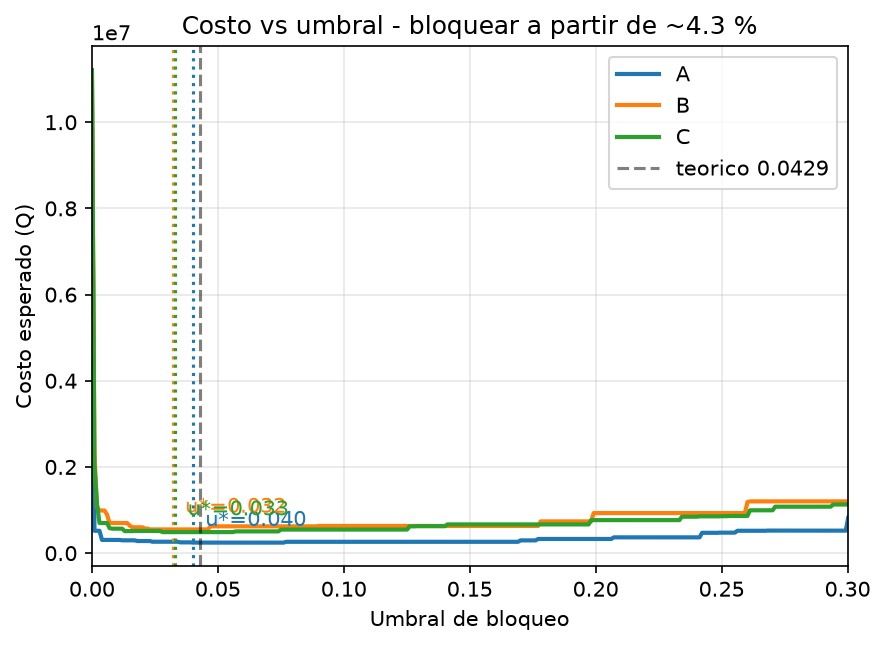

In [31]:
curvas_test = {"A": eco.curva(y_te, p_a_test), "B": eco.curva(y_te, p_b_test),
               "C": eco.curva(y_te, p_c_test)}
figs.curva_costo(curvas_test, {"A": u_a, "B": u_b, "C": u_c},
                 cfg.DIR_FIGURAS / "fig5_costo_test.png")
display(Image(str(cfg.DIR_FIGURAS / "fig5_costo_test.png")))

In [32]:
print("Desglose por mecanismo sobre TEST — donde se concentra la ganancia")
dt = {}
for nombre, p in (("A", crudo_a), ("B", crudo_b), ("C", crudo_c)):
    dt[nombre] = met.desglose_por_tipo(y_te, p, d["subtipo"][te], cfg.UMBRAL_TEORICO).set_index("grupo")
comp_test = pd.DataFrame({
    "n_fraude":  dt["A"]["n_fraude"],
    "auc_pr_A":  dt["A"]["auc_pr"],
    "auc_pr_B":  dt["B"]["auc_pr"],
    "auc_pr_C":  dt["C"]["auc_pr"],
})
comp_test["B_menos_A"] = comp_test["auc_pr_B"] - comp_test["auc_pr_A"]
comp_test

Desglose por mecanismo sobre TEST — donde se concentra la ganancia


,n_fraude,auc_pr_A,auc_pr_B,auc_pr_C,B_menos_A
grupo,,,,,
f1_golpe,57,0.5939,0.6396,0.6009,0.0457
f1_sondeo,250,0.2875,0.1430,0.2076,-0.1445
f2,211,0.9681,0.5828,0.7262,-0.3854
f3,185,0.8313,0.4800,0.7562,-0.3512


---
# 16. Análisis de errores — los casos donde esperábamos fallar

Declarados **antes** de entrenar (§2.4 del enunciado):

> "Esperamos que el modelo falle en clientes con menos de `K` transacciones
> históricas (secuencia rellenada con padding) y en f1 cuando el intervalo
> entre las compras pequeñas y la grande supera las 24 h, porque la ventana
> de `K=20` eventos no alcanza a contener ambos extremos del patrón."

Toca verificarlo empíricamente.

In [33]:
hist_len = d["mask"].sum(axis=1)
cortas = te & (hist_len < cfg.K)
largas = te & (hist_len == cfg.K)

for etiqueta, sel in (("historia < K (con padding)", cortas), ("historia completa", largas)):
    yy = d["y"][sel]
    if yy.sum() == 0:
        print(f"{etiqueta:32s}: sin fraudes en el grupo")
        continue
    pb = exp.predecir_split(modelo_b, d, sel)
    pa = ma.predecir(gbm_a, d["X_A"].to_numpy()[sel])
    print(f"{etiqueta:32s}: n={sel.sum():6,}  fraudes={int(yy.sum()):4d}  "
          f"AUC-PR A={met.auc_pr(yy, pa):.4f}  B={met.auc_pr(yy, pb):.4f}")

historia < K (con padding)      : sin fraudes en el grupo


historia completa               : n=62,974  fraudes= 703  AUC-PR A=0.8499  B=0.6224


In [34]:
# f1 con brecha larga: el golpe queda fuera del alcance de los sondeos
f1_golpes = te & (d["subtipo"] == "f1_golpe")
idx = np.flatnonzero(f1_golpes)
brechas = []
for i in idx:
    ventana = d["win"][i][d["mask"][i]]
    sub_v = d["subtipo"][ventana]
    tiene_sondeo = (sub_v == "f1_sondeo").any()
    brechas.append(tiene_sondeo)
brechas = np.array(brechas)

if len(idx):
    p_golpes = exp.predecir_split(modelo_b, d, f1_golpes)
    print(f"Golpes de f1 en test: {len(idx)}")
    print(f"  con sus sondeos DENTRO de la ventana K=20: {brechas.sum()}  "
          f"-> puntaje medio de B {p_golpes[brechas].mean():.4f}" if brechas.sum() else "")
    print(f"  con los sondeos FUERA de la ventana:       {(~brechas).sum()}  "
          f"-> puntaje medio de B {p_golpes[~brechas].mean():.4f}" if (~brechas).sum() else "")
    print()
    print("Si el segundo grupo puntua mas bajo, el modo de fallo declarado")
    print("se confirma: sin los sondeos a la vista, el golpe es solo una")
    print("compra grande y B no tiene de donde sacar la senal de orden.")

Golpes de f1 en test: 57
  con sus sondeos DENTRO de la ventana K=20: 57  -> puntaje medio de B 0.9816


Si el segundo grupo puntua mas bajo, el modo de fallo declarado
se confirma: sin los sondeos a la vista, el golpe es solo una
compra grande y B no tiene de donde sacar la senal de orden.


---
# 17. Artefactos

In [35]:
# El candidato se elige por AUC-PR de VALIDACION, nunca por el costo en test:
# escoger mirando test cuesta -10 pts. El costo en test solo se reporta.
candidatos_val = {"B — GRU": m_b, "C — Hibrido": m_c}
nombre_candidato = max(candidatos_val, key=candidatos_val.get)
modelo_candidato = {"B — GRU": modelo_b, "C — Hibrido": modelo_c}[nombre_candidato]
u_candidato = {"B — GRU": u_b, "C — Hibrido": u_c}[nombre_candidato]

print("Candidato neuronal al Proyecto Final:", nombre_candidato)
print(f"  elegido por AUC-PR de validacion = {candidatos_val[nombre_candidato]:.4f}")
print()
costos_test = {"A — LightGBM": costo_a_te, "B — GRU": costo_b_te, "C — Hibrido": costo_c_te}
menor_costo = min(costos_test, key=costos_test.get)
print(f"Por separado, el menor costo EN TEST lo obtuvo: {menor_costo} (Q{costos_test[menor_costo]:,.0f}).")
print("Ese dato se reporta, no se usa para elegir nada.")

cfg.DIR_ARTEFACTOS.mkdir(parents=True, exist_ok=True)
modelo_candidato.save(cfg.DIR_ARTEFACTOS / "modelo_candidato.keras")
# La linea base de agregados tambien se conserva: la recomendacion es
# complementar, y un ensamble necesita las dos piezas.
with open(cfg.DIR_ARTEFACTOS / "modelo_a_lightgbm.pkl", "wb") as f:
    pickle.dump(gbm_a, f)

with open(cfg.DIR_ARTEFACTOS / "scaler.pkl", "wb") as f:
    pickle.dump({"eventos": d["scaler"], "agregados": d["esc_agg"]}, f)

(cfg.DIR_ARTEFACTOS / "vocab_embeddings.json").write_text(
    json.dumps({k: {str(a): b for a, b in v.items()} for k, v in d["vocab"].items()}, indent=2),
    encoding="utf-8")

(cfg.DIR_ARTEFACTOS / "config.json").write_text(json.dumps({
    "K": cfg.K,
    "seed_datos": cfg.SEED_DATOS,
    "seeds_modelo": list(cfg.SEEDS_MODELO),
    "modelo_candidato": nombre_candidato,
    "criterio_de_seleccion": "AUC-PR de validacion (nunca costo en test)",
    "menor_costo_en_test": menor_costo,
    "umbral_u_estrella": {"A": u_a, "B": u_b, "C": u_c, "candidato": u_candidato},
    "umbral_teorico": cfg.UMBRAL_TEORICO,
    "costos": {"FN": cfg.COSTO_FN, "FP": cfg.COSTO_FP},
    "batch_size": cfg.BATCH_SIZE,
    "auc_pr_validacion": {"A": m_gbm, "B": m_b, "C": m_c},
    "auc_pr_test": {r["modelo"]: r["auc_pr"] for _, r in tabla_test.iterrows()},
    "costo_test_Q": {"A": costo_a_te, "B": costo_b_te, "C": costo_c_te},
    "ahorro_mensual_Q": {"B_vs_A": ahorro_b, "C_vs_A": ahorro_c},
    "dias_test": dias_test,
    "fecha_hipotesis_C": FECHA_HIPOTESIS,
    "fecha_ejecucion_test": FECHA_EJECUCION_TEST,
    "versiones": rep.versiones(),
}, indent=2), encoding="utf-8")

shutil.copy(cfg.RAIZ / "src" / "monitoreo" / "generador.py",
            cfg.DIR_ARTEFACTOS / "generador_datos.py")

for p in sorted(cfg.DIR_ARTEFACTOS.glob("*")):
    if p.is_file():
        print(f"  {p.name:28s} {p.stat().st_size/1024:8.1f} KB")

Candidato neuronal al Proyecto Final: B — GRU
  elegido por AUC-PR de validacion = 0.7138

Por separado, el menor costo EN TEST lo obtuvo: A — LightGBM (Q244,560).
Ese dato se reporta, no se usa para elegir nada.


  config.json                       1.4 KB
  generador_datos.py               14.1 KB
  modelo_a_lightgbm.pkl           464.2 KB
  modelo_candidato.keras          367.3 KB
  scaler.pkl                        1.4 KB
  vocab_embeddings.json             5.2 KB


In [36]:
# Todas las cifras del informe en un solo JSON, para que el informe se
# escriba desde los datos y no copiando numeros a mano.
resultados = {
    "K": cfg.K,
    "seed_datos": cfg.SEED_DATOS,
    "costos": {"FN": cfg.COSTO_FN, "FP": cfg.COSTO_FP},
    "n_eventos": int(len(d["df"])),
    "n_test": int(te.sum()),
    "n_fraude_test": int(y_te.sum()),
    "n_legitimas_test": int((y_te == 0).sum()),
    "n_tarjetas": int(d["df"]["card_id"].nunique()),
    "tasa_fraude_global": float(d["y"].mean()),
    "particion": json.loads(part.tabla(d["df"], d["split"]).to_json(orient="records", date_format="iso")),
    "validacion": {
        "auc_pr": {"A_logistica": [m_log, s_log], "A_gbm": [m_gbm, s_gbm],
                   "B_gru": [m_b, s_b], "C_hibrido": [m_c, s_c]},
        "prevalencia": float(y_va.mean()),
    },
    "permutacion": json.loads(tabla4.to_json(orient="records")),
    "ablacion_delta_t": {"con": float(res_b[cfg.SEEDS_MODELO[0]]["auc_pr"]),
                         "sin": float(r_sin_dt["auc_pr"])},
    "curva_k": json.loads(tabla_k.to_json(orient="records")),
    "apuesta_C": {"hipotesis": HIPOTESIS_C, "fecha": FECHA_HIPOTESIS,
                  "umbral_exito": UMBRAL_EXITO_C, "mejor_puro": float(mejor_puro),
                  "C": float(m_c), "ganancia": float(ganancia),
                  "se_sostuvo": bool(se_sostuvo)},
    "desglose_validacion": json.loads(comparacion.to_json(orient="index")),
    "desglose_test": json.loads(comp_test.to_json(orient="index")),
    "umbrales": {"A": u_a, "B": u_b, "C": u_c, "teorico": cfg.UMBRAL_TEORICO},
    "test": json.loads(tabla_test.to_json(orient="records")),
    "economia": {"costo_A": costo_a_te, "costo_B": costo_b_te, "costo_C": costo_c_te,
                 "ahorro_mensual_B": ahorro_b, "ahorro_mensual_C": ahorro_c,
                 "dias_test": dias_test, "tx_por_dia": tx_por_dia},
    "candidato": nombre_candidato,
    "menor_costo_en_test": menor_costo,
    "fecha_ejecucion_test": FECHA_EJECUCION_TEST,
}
(cfg.DIR_ARTEFACTOS / "resultados_informe.json").write_text(
    json.dumps(resultados, indent=2, default=str), encoding="utf-8")
print("Escrito artefactos/resultados_informe.json")
print(json.dumps({k: v for k, v in resultados.items()
                  if k in ("candidato", "menor_costo_en_test", "fecha_ejecucion_test")}, indent=2))

Escrito artefactos/resultados_informe.json


{
  "candidato": "B \u2014 GRU",
  "menor_costo_en_test": "A \u2014 LightGBM",
  "fecha_ejecucion_test": "2026-09-03T01:22:43"
}


---
# 18. Recomendación

**Complementar, no reemplazar.** El desglose por mecanismo es la razón: la
ganancia del orden se concentra en f1 y no aparece en f2 ni en f3, que son
la mayoría de los episodios. El motor actual de agregados sigue siendo más
barato de operar y mucho más explicable ante un cliente al que se le
bloqueó una compra.

La forma concreta: el motor de agregados como primer filtro y el modelo
secuencial como segundo, o el máximo de los dos puntajes calibrados. Eso
captura la ganancia en f1 sin renunciar a la explicabilidad en el resto.

**Límites de esta evidencia.** Los datos son sintéticos y el generador lo
escribimos nosotros; lo que el experimento demuestra es que *si* existe un
patrón dependiente del orden como f1, un GRU lo encuentra y los agregados
no. No demuestra que ese patrón exista en el flujo real del banco, ni con
qué prevalencia. La matriz de evidencias del informe lleva una limitación
por fila.